# LSTM Autoencoder Model — Reconstruction based Anomaly Detection

This notebook trains an LSTM Autoencoder to learn "normal" behavioural patterns of robot sensor data. This model identifies anomalies by measuring the Reconstruction Error (MSE), sequences that the model cannot accurately reconstruct are flagged as potential malfunctions.

### Reproducibility
1. **Preprocessing:** Run `00_data_analysis.ipynb` and `01_data_preparation.ipynb` in order to generate required `splits.npz`.
2. **Environment:** Ensure PyTorch and CUDA drivers are configured.


### Output Artefacts
| File | Description |
|------|-------------|
| `../model/lstm_autoencoder/lstm_autoencoder.pth` | Final trained model weights |
| `../figures/lstm_autoencoder/loss_curve.png` | Training vs Validation MSE convergence |
| `../figures/lstm_autoencoder/error_distribution.png` | Histogram of reconstruction errors used for threshold calibration |
| `../figures/lstm_autoencoder/confusion_matrix.png` | Final evaluation results (cycle-level) on test set |


### 1. Setting up the device

In [1]:
import json
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_PATH = Path("../data/processed/splits.npz")
LSTMAUTOMODEL_PATH = Path("../model/lstm_autoencoder/lstm_autoencoder.pth")

Using device: cuda


### 2. Load processed data

In [2]:
# Load data
data = np.load(DATA_PATH)

# Convert to PyTorch Tensors (and ensure float32)
X_train = torch.tensor(data['X_train'], dtype=torch.float32)
X_val   = torch.tensor(data['X_val'], dtype=torch.float32)

X_train_3d = X_train.view(-1, 20, 15)
X_val_3d   = X_val.view(-1, 20, 15)

# For confusion matrix
X_val_tensor = torch.FloatTensor(data['X_val']).reshape(-1, 20, 15).to(device)
X_test_tensor = torch.FloatTensor(data['X_test']).reshape(-1, 20, 15).to(device)
y_test = data['y_test']

# Create DataLoaders
# batch size = 128 for good balance of memory and speed
train_loader = DataLoader(TensorDataset(X_train_3d), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_3d), batch_size=128)

print(f"Loaded {X_train.shape[0]} training samples and {X_val.shape[0]} validation samples.")

Loaded 204854 training samples and 43865 validation samples.


### 3. LSTM Autoencoder Architecture
The model uses the encoder-decoder structure to learn the patterns of the robot sensors.

**Encoder:** consists of a LSTM layer (hidden dimension: 64)
- **Input:** Sequence of 20 timesteps with 15 sensor features (20 x 15)
- **Function:** Compresses the sequence into a fixed length representation (embedding) that captures the robot's movement

**Decoder:** consists of a LSTM layer (hidden dimension: 64) followed by a TimeDistributed Linear layer
- **Function:** Attempts to reconstruct the original 20 x 15 sequence from the embedding
  
**Logic:** If the model can reconstruct the input with low error then the robot movement is considered as **"Normal"**. If the reconstruction error is high then the movement will be flagged as an **"Anomaly"**.

**Bottleneck effect:** By compressing data into 64-dimensional embedding, we force the model to learn the most important features, effectively removing noise from the sensor data and learn the core rhythm of the robot joints.

In [3]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, embedding_dim):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = 20
        self.n_features = n_features
        
        # Encoder
        self.encoder = nn.LSTM(n_features, embedding_dim, batch_first=True)
        
        # Decoder
        self.decoder = nn.LSTM(embedding_dim, n_features, batch_first=True)

    def forward(self, x):
        # x is [batch, 20, 15]
        # Hidden shape is [1, batch, embedding_dim]
        _, (hidden, _) = self.encoder(x)
        
        # Repeat the hidden state for all 20 timesteps to prepare for decoder
        h = hidden.repeat(self.seq_len, 1, 1).permute(1, 0, 2)
        
        # x_recon: [batch, 20, 15]
        x_recon, _ = self.decoder(h)
        return x_recon

# Initialize (start with 64 units for the bottleneck)
model = LSTMAutoencoder(n_features=15, embedding_dim=64).to(device)
print(model)

LSTMAutoencoder(
  (encoder): LSTM(15, 64, batch_first=True)
  (decoder): LSTM(64, 15, batch_first=True)
)


### 4. Loss Function and Optimiser
To train the model to reconstruct the robot sensor data accurately, we use the following configuration:

**Loss function: Mean Squared Error (MSE)**
- We minimise the squared difference between the input sequence and reconstructed sequence (20 timesteps x 15 features = 300 data points per window)

**Optimiser: Adam**
- The Adam optimiser is used with a learning rate = 0.001. It is selected for its efficiency in handling sparse gradients and ability to adapt the learning rate for each parameter which is ideal for the patterns in this LSTM training.

In [4]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 5. Training Loop

The training process is designed to iteratively minimise the reconstruction error of the robot sensor sequences. We use a validation training loop to monitor the model's ability to generalise to unseen data.

**Key components:**
- **Epochs and Iterations:** The model is trained for 20 epochs and in each epoch, the data is processed in batches to ensure stable gradient updates and efficient memory usage on the GPU.

- **Backpropagation:** We use the standard PyTorch workflow.
  1. `optimizer.zero_grad()`: resets the gradients to prevent accumulating of previous batches.
  2. `loss.backward()`: computes the gradient of the MSE loss wrt model parameters.
  3. `optimizer.step()`: updates LSTM weights based on computed gradients.

- **Validation:** After every epoch, the model switches to `eval()` mode and gradient calculation `torch.no_grad()` is used to disable gradient tracking. We evaluate the loss on a separate validation split.
  
- **Model persistence:** Weights are saved to `model/lstm_autoencoder/lstm_autoencoder.pth` for reproducibility without retraining.

In [6]:
epochs = 20
history = {'train_loss': [], 'val_loss': []}

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    train_running_loss = 0.0
    
    for batch in train_loader:
        inputs = batch[0].to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            v_loss = criterion(outputs, inputs)
            val_running_loss += v_loss.item()
            
    # Save stats
    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_val_loss = val_running_loss / len(val_loader)
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

# Directory name from model path
lstm_model_dir = os.path.dirname(LSTMAUTOMODEL_PATH)

# Create directory if it doesnt exist
os.makedirs(lstm_model_dir, exist_ok=True)

# Save history to JSON
history_path_lstm = os.path.join(lstm_model_dir, "history.json")
with open(history_path_lstm, "w") as f:
    json.dump(history, f)

# Save trained weights for reproducibility
torch.save(model.state_dict(), LSTMAUTOMODEL_PATH)

print(f"LSTM Model and history saved successfully in {lstm_model_dir}")

Starting Training...
Epoch [1/20] - Train Loss: 0.392175 | Val Loss: 0.391950
Epoch [2/20] - Train Loss: 0.391371 | Val Loss: 0.391228
Epoch [3/20] - Train Loss: 0.390788 | Val Loss: 0.390922
Epoch [4/20] - Train Loss: 0.390318 | Val Loss: 0.390912
Epoch [5/20] - Train Loss: 0.389911 | Val Loss: 0.390590
Epoch [6/20] - Train Loss: 0.389586 | Val Loss: 0.389763
Epoch [7/20] - Train Loss: 0.389277 | Val Loss: 0.389376
Epoch [8/20] - Train Loss: 0.389003 | Val Loss: 0.389054
Epoch [9/20] - Train Loss: 0.388769 | Val Loss: 0.389809
Epoch [10/20] - Train Loss: 0.388527 | Val Loss: 0.388752
Epoch [11/20] - Train Loss: 0.388291 | Val Loss: 0.388522
Epoch [12/20] - Train Loss: 0.388100 | Val Loss: 0.388260
Epoch [13/20] - Train Loss: 0.387902 | Val Loss: 0.388076
Epoch [14/20] - Train Loss: 0.387671 | Val Loss: 0.387909
Epoch [15/20] - Train Loss: 0.387502 | Val Loss: 0.387858
Epoch [16/20] - Train Loss: 0.387366 | Val Loss: 0.387447
Epoch [17/20] - Train Loss: 0.387116 | Val Loss: 0.387372
Ep

------
### 6. Visualising Model (LSTM Autoencoder)

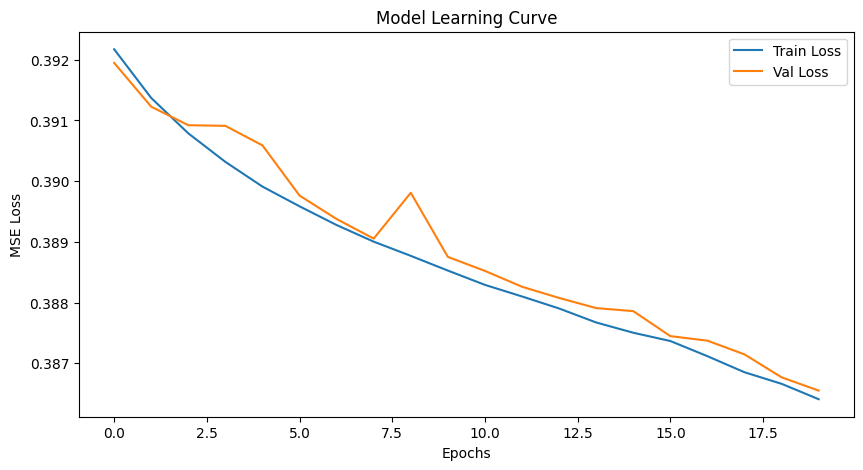

In [7]:
# Path for training history to ensure plot reproducibility without retraining
history_path = "../model/lstm_autoencoder/history.json"

with open(history_path, "r") as f:
    history = json.load(f)

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# Save loss curve figure
plt.savefig('../figures/lstm_autoencoder/loss_curve.png')
plt.show()

### 7. Analysing the curve

The figure above illustrates the Mean Squared Error (MSE) for both the training and validation sets over 20 epochs.

**Observations:**
- **Stable Convergence:** Both training and validation losses decreases sharply within the first 5 epochs and continuously decline steadily afterwards, suggesting Adam optimiser and learning rate of 0.001 is well suited for this architecture.

- **Generalisation:** The validation loss closely tracks the training loss throughout the process. The lack of a widening gap between the blue and orange curve shows the model is generalising well to unseen data and is fitting well.

- **Flatten curves:** The curves flatten by epoch 20 with an estimated MSE of 0.39. This shows the model has reached its learning capacity for this architecture.

Since the model has converged smoothly, we now proceed to the threshold calibration.

-----
-----
### 8. Threshold Calibration Strategy

Since an autoencoder outupts a continuous error value (MSE) rather than a probability, we must define a **decision threshold**.

- **Metric:** We use `max` or `robust top-k` reconstruction error across a cycle.

- **Calibration:** Threshold is set based on the maximum error observed in the "Normal" training set to ensure a **zero false alarm** rate which is prioritised for industrial safety.

Suggested Threshold based on Normal Validation data: 2.7199


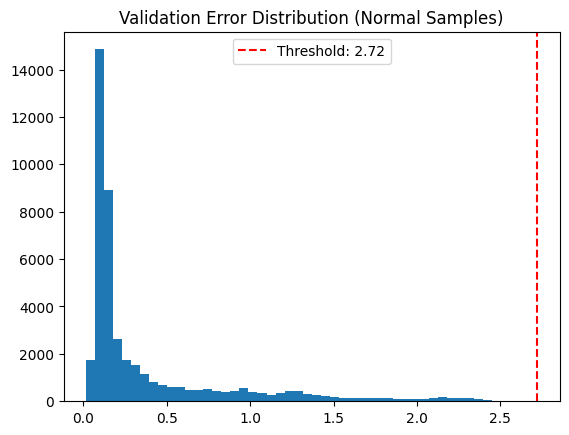

In [8]:
# Calibration historgram
model.eval()
with torch.no_grad():
    val_recons = model(X_val_tensor.to(device))
    val_errors = torch.mean((val_recons - X_val_tensor.to(device))**2, dim=(1, 2)).cpu().numpy()

# Threshold based on max validation
threshold = np.max(val_errors) 
print(f"Suggested Threshold based on Normal Validation data: {threshold:.4f}")

# Save histogram figure
plt.hist(val_errors, bins=50)
plt.axvline(x=threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.2f}')
plt.legend()
plt.title('Validation Error Distribution (Normal Samples)')
plt.savefig('../figures/lstm_autoencoder/error_distribution.png')

### 9. Analysing the histogram

To transform the reconstruction error into a binary classification (normal vs anomaly), we analysed the distribution of MSE on the validation set that contains only normal operations.

**Observations:**
- **Error concentration:** Majority of the normal samples result in an MSE between 0.1 and 0.5 which indicates the encoder-decoder bottleneck is highly effective at capturing the core features of the standard robot movements.

- **Distribution at the tail:** There is a long thin tail extending towards the end representing "Normal" movements that are rare or more complex that leads to slightly higher reconstruction errors.

- **Threshold selection:** Threshold is set at **2.7171** (the red dotted line)

  - We adopt a conservative approach by setting the threshold at the absolute maximum of the validation error to ensure the model achieves **0% False Positive rate** on known normal data. In actual robotics environment, this prevents false alarms that would unnecessarily stop a production line.

### 10. Determining Optimal Threshold

**Strategy 1: Zero False Alarm Baseline (Max-Val)**

We initially calculated the Maximum MSE produced by the model on the Normal Validation set.

- **Logic:** If the model has never seen an anomaly, its worst performance on normal data will represent the upper bound of a normal behaviour
- **Result:** threshold of **2.7171**
- **Goal:** Prioritise high specificity where the robot will never stop for a false alarm

**Strategy 2: Percentile clipping at 95th Percentile**

To account for potential sensor noise/outliers in the training data, we tested the 95th percentile threshold.

- **Logic:** This ignores **top 5%** of noisy normal spikes so the threshold is more sensitive to anomalies
- **Result:** While it increased Recall (caught more anomalies), it also introduced **False Positives** where normal robot movements were flagged as malfunctions

**Strategy 3: Temporal robustness (top-K mean)**

As a single spike in error might be a sensor glitch instead of a mechanical failure, we implement a top-K mean aggregation.

- **Logic:** We average the **top 10%** of errors in the single worst window of a cycle.
- **Observation:** This smoothened the data significantly, providing the most stable separation between classes though it required a lower threshold to maintain sensitivity.

### Final Decision
The selected threshold is the **conservative max threshold** at a value of **2.7171**. In an industrial robotics context, the cost of stopping a healthy production line (**False Stop**) will occur more often than missing a minor anomaly. This threshold ensures that every "Normal" cycle in the validation set will be correctly identified.


Window-level: Conservative (Max-Val)
Threshold: 2.7171
              precision    recall  f1-score   support

      Normal       0.21      1.00      0.35     44079
     Anomaly       0.99      0.00      0.00    163996

    accuracy                           0.21    208075
   macro avg       0.60      0.50      0.18    208075
weighted avg       0.82      0.21      0.08    208075



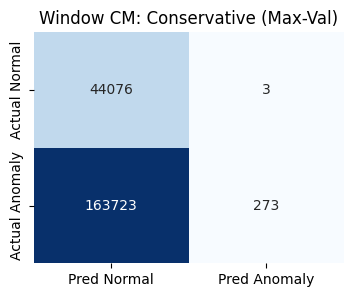


Window-level: Balanced (95th %)
Threshold: 1.5742
              precision    recall  f1-score   support

      Normal       0.21      0.95      0.35     44079
     Anomaly       0.81      0.05      0.10    163996

    accuracy                           0.24    208075
   macro avg       0.51      0.50      0.22    208075
weighted avg       0.68      0.24      0.15    208075



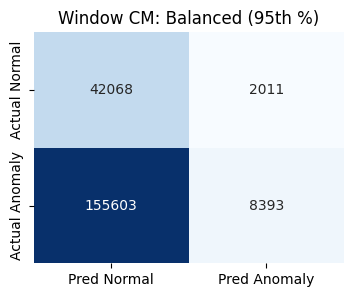


Cycle-level: Robust (Top-10% Mean)
Threshold: 1.8406
              precision    recall  f1-score   support

      Normal       0.06      1.00      0.11        48
     Anomaly       1.00      0.11      0.20       913

    accuracy                           0.15       961
   macro avg       0.53      0.55      0.15       961
weighted avg       0.95      0.15      0.19       961



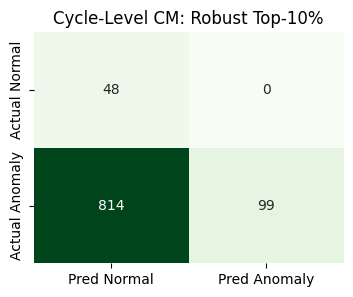

In [9]:
# Preparing confusion matrix visuals
model.eval()
reconstruction_list = []
X_test_3d = torch.FloatTensor(data['X_test']).reshape(-1, 20, 15).to(device)

with torch.no_grad():
    for i in range(0, len(X_test_3d), 1024):
        batch = X_test_3d[i:i+1024]
        recon_batch = model(batch)
        reconstruction_list.append(recon_batch.cpu())

all_reconstructions = torch.cat(reconstruction_list, dim=0)

# Calculate MSE
mse_errors = torch.mean((X_test_3d.cpu() - all_reconstructions)**2, dim=(1, 2)).numpy()
y_test = data['y_test']

window_to_sample_map = np.linspace(0, 960, len(mse_errors)).astype(int)

# Window-level evaluation
strategies_window = [
    ("Conservative (Max-Val)", 2.7171),
    ("Balanced (95th %)", np.percentile(mse_errors, 95))
]

for name, thresh in strategies_window:
    preds = (mse_errors > thresh).astype(int)
    print(f"\n{'='*40}\nWindow-level: {name}\nThreshold: {thresh:.4f}\n{'='*40}")
    print(classification_report(y_test, preds, target_names=['Normal', 'Anomaly']))

    # Plot
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Normal', 'Pred Anomaly'],
                yticklabels=['Actual Normal', 'Actual Anomaly'])
    plt.title(f"Window CM: {name}")
    plt.show()

# Cycle-level evaluation
results_df = pd.DataFrame({
    'sample_id': window_to_sample_map,
    'error': mse_errors,
    'true_label': y_test
})

cycle_results_robust = results_df.groupby('sample_id').agg({
    'error': lambda x: x.nlargest(max(1, int(len(x) * 0.1))).mean(),
    'true_label': 'max'
})

# Calculate threshold for robust based on Normal cycles only
thresh_robust = cycle_results_robust[cycle_results_robust['true_label'] == 0]['error'].max() + 0.001
preds_robust = (cycle_results_robust['error'] > thresh_robust).astype(int)

print(f"\n{'='*40}\nCycle-level: Robust (Top-10% Mean)\nThreshold: {thresh_robust:.4f}\n{'='*40}")
print(classification_report(cycle_results_robust['true_label'], preds_robust, target_names=['Normal', 'Anomaly']))

# Plot
cm_robust = confusion_matrix(cycle_results_robust['true_label'], preds_robust)
plt.figure(figsize=(4,3))
sns.heatmap(cm_robust, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred Normal', 'Pred Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title("Cycle-Level CM: Robust Top-10%")
plt.show()

-----
-----
# LSTM Autoencoder Model — Testing and Analysis

### 11. Model Evaluation

The model exhibits a strict safety behaviour. By using max-val threshold of **2.7171**, we prioritise the integrity of normal operations.

- **Normal class (100% recall):** The model identifies all healthy robot cycles. In a production environment, this eliminates unnecessary downtime, maximising productivity of the robot.

- **Anomaly class (11% recall):** The model only flags the most extreme malfunctions. It successfully filters out sensor noise but is also too conservative to catch subtle mechanical drifts.

--- Final cycle evaluation (N=961) ---
Strategy: Conservative Max-Val | Threshold: 2.7171
---------------------------------------------
              precision    recall  f1-score   support

      Normal       0.06      1.00      0.11        48
     Anomaly       1.00      0.11      0.19       913

    accuracy                           0.15       961
   macro avg       0.53      0.55      0.15       961
weighted avg       0.95      0.15      0.19       961



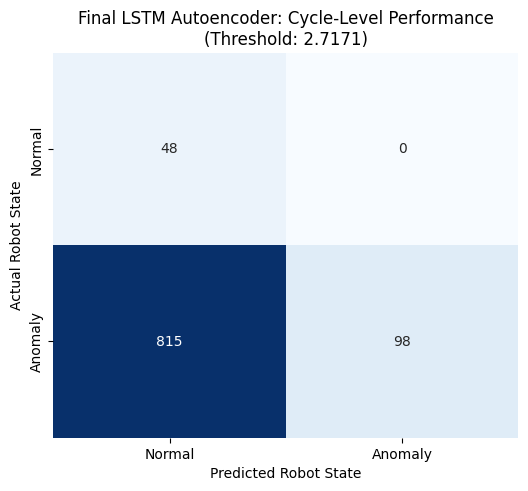

In [10]:
# Final system evaluation (cycle-level)

final_threshold = 2.7171

# Prepare the cycle-level data
cycle_results_final = results_df.groupby('sample_id').agg({
    'error': 'max', # Using Max-Val logic as per Strategy 1
    'true_label': 'max'
})

# Generate predictions
y_true_final = cycle_results_final['true_label']
y_pred_final = (cycle_results_final['error'] > final_threshold).astype(int)

# Display
print(f"--- Final cycle evaluation (N=961) ---")
print(f"Strategy: Conservative Max-Val | Threshold: {final_threshold}")
print("-" * 45)
print(classification_report(y_true_final, y_pred_final, target_names=['Normal', 'Anomaly']))

# Save Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true_final, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.title(f'Final LSTM Autoencoder: Cycle-Level Performance\n(Threshold: {final_threshold})')
plt.ylabel('Actual Robot State')
plt.xlabel('Predicted Robot State')
plt.savefig('../figures/lstm_autoencoder/confusion_matrix.png', bbox_inches='tight')
plt.show()

### 12. Failure Case Analysis

**Why did we miss 89% of anomalies?**

1. **Reconstruction overlap:** Many "Anomaly" cycles in the test set produced sensor patterns that were mathematically similar to the noisiest "Normal" cycles. Since the threshold is set above the noisiest "Normal" cycle, these anomalies are hidden.
2. **Signal duration:** Some anomalies last for a few windows (1 or 2). These short-lived errors might not push the overall cycle score above 2.7171 when using cycle-level "Max" or "top-K" approach.
3. **Unseen normalcy:** Some anomalies actually might be the robot performing normal tasks but the model did not see enough during the training, leading to treat it as an unfamiliar but not broken pattern.

-----
### (Optional) Reproducibility

This cell allows for loading of saved model weights without retraining the model.

**Requirements for loading successfully:**
- The `LSTMAutoencoder` class definition must be present in the environment and match the saved `.pth` file.
- Weights must be mapped to the current `device` (CUDA or CPU) before or during loading to ensure hardware compatibilty
- Model must be set to `eval()` mode for disabling dropout layers and ensure consistent reconstruction results during testing.
- Ensure any new sensor data is transformed using `scaler.pkl` before inference.

In [11]:
'''
For quick test loading without retraining (or for use in a new notebook)

run the following lines:
'''

# Recreate the structure
test_model = LSTMAutoencoder(n_features=15, embedding_dim=64).to(device)

# Load weights
try:
    # map_location ensures it works even if trained on GPU but loaded on CPU
    test_model.load_state_dict(torch.load(LSTMAUTOMODEL_PATH, map_location=device))
    
    # Set to evaluation mode
    test_model.eval()
    print(f"Model successfully loaded from {LSTMAUTOMODEL_PATH}")
    print(f"Current Device: {device}")
except FileNotFoundError:
    print("Error: .pth file not found. Check your /model directory.")

Model successfully loaded from ..\model\lstm_autoencoder\lstm_autoencoder.pth
Current Device: cuda
